# Import Required Libraries

In [84]:
import pandas as pd

# Load Dataset

In [85]:
df = pd.read_csv("factory_sensor.csv.xls")
print(df.head())
print(df.info())

  Machine_ID        Machine_Type  Installation_Year  Operational_Hours  \
0  MC_000000               Mixer               2027              81769   
1  MC_000001  Industrial_Chiller               2032              74966   
2  MC_000002      Pick_and_Place               2003              94006   
3  MC_000003       Vision_System               2007              76637   
4  MC_000004      Shuttle_System               2016              20870   

   Temperature_C  Vibration_mms  Sound_dB  Oil_Level_pct  Coolant_Level_pct  \
0          73.43          12.78     83.72          36.76              68.74   
1          58.32          14.99     77.04         100.00              62.13   
2          49.63          23.78     69.08          42.96              35.96   
3          63.73          12.38     85.58          94.90              48.94   
4          42.77           4.42     96.72          47.56              53.78   

   Power_Consumption_kW  ...  Failure_History_Count  AI_Supervision  \
0        

In [86]:
print(df.isnull().sum())
print(df.describe())

Machine_ID                         0
Machine_Type                       0
Installation_Year                  0
Operational_Hours                  0
Temperature_C                      0
Vibration_mms                      0
Sound_dB                           0
Oil_Level_pct                      0
Coolant_Level_pct                  0
Power_Consumption_kW               0
Last_Maintenance_Days_Ago          0
Maintenance_History_Count          0
Failure_History_Count              0
AI_Supervision                     0
Error_Codes_Last_30_Days           0
Remaining_Useful_Life_days         0
Failure_Within_7_Days              0
Laser_Intensity               484844
Hydraulic_Pressure_bar        469660
Coolant_Flow_L_min            454376
Heat_Index                    454786
AI_Override_Events                 0
dtype: int64
       Installation_Year  Operational_Hours  Temperature_C  Vibration_mms  \
count      500000.000000      500000.000000  500000.000000   500000.00000   
mean         2019.9

In [87]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Machine_ID                     0.0000
Machine_Type                   0.0000
Installation_Year              0.0000
Operational_Hours              0.0000
Temperature_C                  0.0000
Vibration_mms                  0.0000
Sound_dB                       0.0000
Oil_Level_pct                  0.0000
Coolant_Level_pct              0.0000
Power_Consumption_kW           0.0000
Last_Maintenance_Days_Ago      0.0000
Maintenance_History_Count      0.0000
Failure_History_Count          0.0000
AI_Supervision                 0.0000
Error_Codes_Last_30_Days       0.0000
Remaining_Useful_Life_days     0.0000
Failure_Within_7_Days          0.0000
Laser_Intensity               96.9688
Hydraulic_Pressure_bar        93.9320
Coolant_Flow_L_min            90.8752
Heat_Index                    90.9572
AI_Override_Events             0.0000
dtype: float64


In [88]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [89]:
print(df.dtypes)

Machine_ID                     object
Machine_Type                   object
Installation_Year               int64
Operational_Hours               int64
Temperature_C                 float64
Vibration_mms                 float64
Sound_dB                      float64
Oil_Level_pct                 float64
Coolant_Level_pct             float64
Power_Consumption_kW          float64
Last_Maintenance_Days_Ago       int64
Maintenance_History_Count       int64
Failure_History_Count           int64
AI_Supervision                   bool
Error_Codes_Last_30_Days        int64
Remaining_Useful_Life_days    float64
Failure_Within_7_Days            bool
Laser_Intensity               float64
Hydraulic_Pressure_bar        float64
Coolant_Flow_L_min            float64
Heat_Index                    float64
AI_Override_Events              int64
dtype: object


In [90]:
df = df.drop(columns=[
    "Machine_ID",
    "Laser_Intensity",
    "Hydraulic_Pressure_bar",
    "Coolant_Flow_L_min",
    "Heat_Index",
    "Remaining_Useful_Life_days", 
], errors='ignore')

print(df.head())

         Machine_Type  Installation_Year  Operational_Hours  Temperature_C  \
0               Mixer               2027              81769          73.43   
1  Industrial_Chiller               2032              74966          58.32   
2      Pick_and_Place               2003              94006          49.63   
3       Vision_System               2007              76637          63.73   
4      Shuttle_System               2016              20870          42.77   

   Vibration_mms  Sound_dB  Oil_Level_pct  Coolant_Level_pct  \
0          12.78     83.72          36.76              68.74   
1          14.99     77.04         100.00              62.13   
2          23.78     69.08          42.96              35.96   
3          12.38     85.58          94.90              48.94   
4           4.42     96.72          47.56              53.78   

   Power_Consumption_kW  Last_Maintenance_Days_Ago  Maintenance_History_Count  \
0                 84.95                        153               

In [91]:
df = pd.get_dummies(df, columns=["Machine_Type"], drop_first=True)

print(df.head())

   Installation_Year  Operational_Hours  Temperature_C  Vibration_mms  \
0               2027              81769          73.43          12.78   
1               2032              74966          58.32          14.99   
2               2003              94006          49.63          23.78   
3               2007              76637          63.73          12.38   
4               2016              20870          42.77           4.42   

   Sound_dB  Oil_Level_pct  Coolant_Level_pct  Power_Consumption_kW  \
0     83.72          36.76              68.74                 84.95   
1     77.04         100.00              62.13                154.61   
2     69.08          42.96              35.96                 51.90   
3     85.58          94.90              48.94                 75.61   
4     96.72          47.56              53.78                224.93   

   Last_Maintenance_Days_Ago  Maintenance_History_Count  ...  \
0                        153                          4  ...   
1     

In [92]:
print(df.columns)

Index(['Installation_Year', 'Operational_Hours', 'Temperature_C',
       'Vibration_mms', 'Sound_dB', 'Oil_Level_pct', 'Coolant_Level_pct',
       'Power_Consumption_kW', 'Last_Maintenance_Days_Ago',
       'Maintenance_History_Count', 'Failure_History_Count', 'AI_Supervision',
       'Error_Codes_Last_30_Days', 'Failure_Within_7_Days',
       'AI_Override_Events', 'Machine_Type_AGV',
       'Machine_Type_Automated_Screwdriver', 'Machine_Type_Boiler',
       'Machine_Type_CMM', 'Machine_Type_CNC_Lathe', 'Machine_Type_CNC_Mill',
       'Machine_Type_Carton_Former', 'Machine_Type_Compressor',
       'Machine_Type_Conveyor_Belt', 'Machine_Type_Crane',
       'Machine_Type_Dryer', 'Machine_Type_Forklift_Electric',
       'Machine_Type_Furnace', 'Machine_Type_Grinder',
       'Machine_Type_Heat_Exchanger', 'Machine_Type_Hydraulic_Press',
       'Machine_Type_Industrial_Chiller', 'Machine_Type_Injection_Molder',
       'Machine_Type_Labeler', 'Machine_Type_Laser_Cutter',
       'Machine_Type

In [93]:
df["Machine_Age"] = 2025 - df["Installation_Year"]
print(df["Machine_Age"])

0         -2
1         -7
2         22
3         18
4          9
          ..
499995    14
499996    22
499997   -14
499998   -10
499999     4
Name: Machine_Age, Length: 500000, dtype: int64


In [94]:
Q1 = df["Machine_Age"].quantile(0.25)
Q3 = df["Machine_Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Machine_Age"] < lower_bound) | (df["Machine_Age"] > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [95]:
df.loc[df["Installation_Year"] > 2025, "Installation_Year"] = 2025

In [96]:
df["Machine_Age"] = 2025 - df["Installation_Year"]
print(df["Machine_Age"])

0          0
1          0
2         22
3         18
4          9
          ..
499995    14
499996    22
499997     0
499998     0
499999     4
Name: Machine_Age, Length: 500000, dtype: int64


In [97]:
df.drop(columns=["Installation_Year"], inplace=True)

In [98]:
y = df["Failure_Within_7_Days"]

In [99]:
X = df.drop("Failure_Within_7_Days", axis=1)

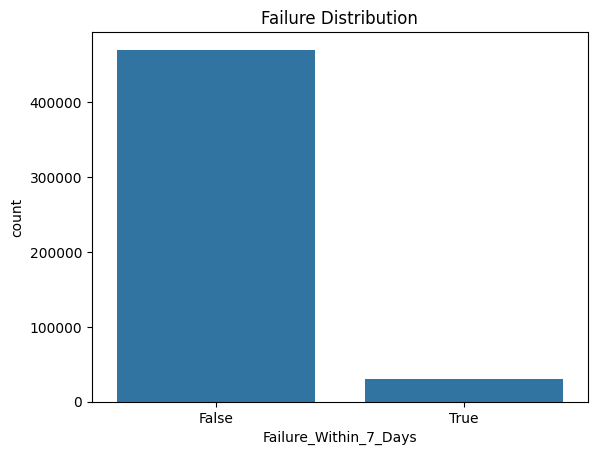

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Failure_Within_7_Days", data=df)
plt.title("Failure Distribution")
plt.show()

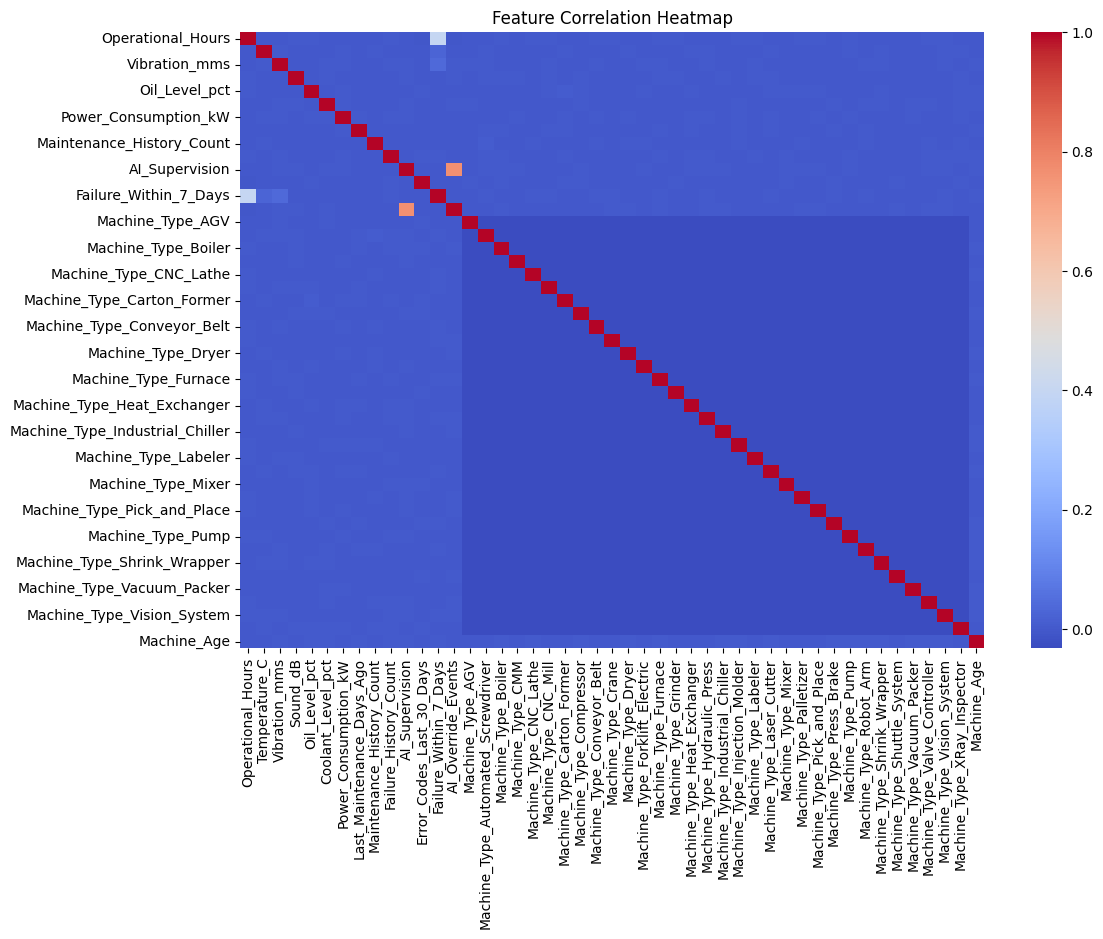

In [101]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

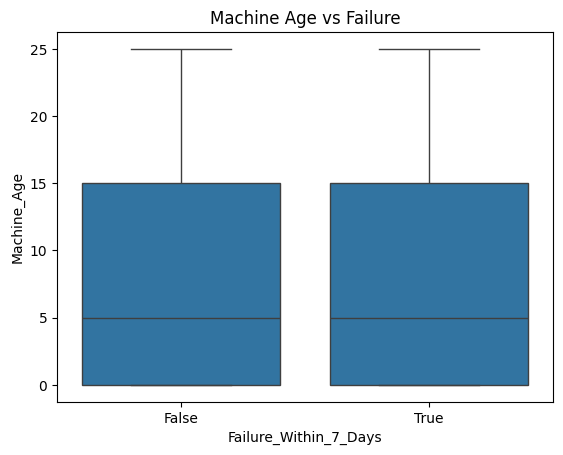

In [102]:
sns.boxplot(x="Failure_Within_7_Days", y="Machine_Age", data=df)
plt.title("Machine Age vs Failure")
plt.show()

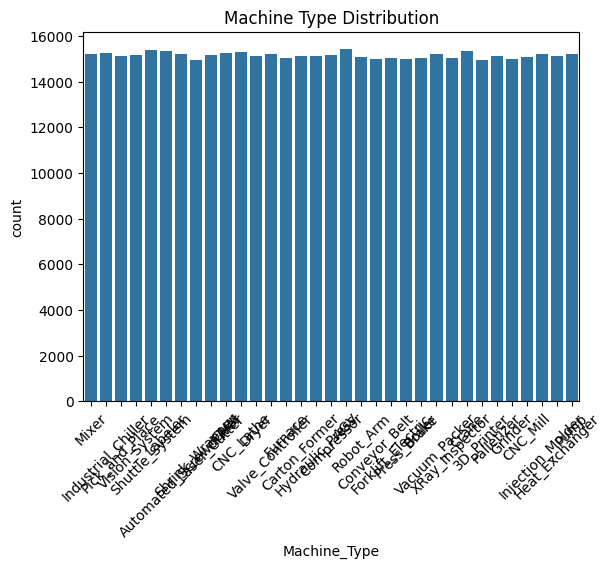

In [103]:
sns.countplot(x="Machine_Type", data=pd.read_csv("factory_sensor.csv.xls"))
plt.xticks(rotation=45)
plt.title("Machine Type Distribution")
plt.show()

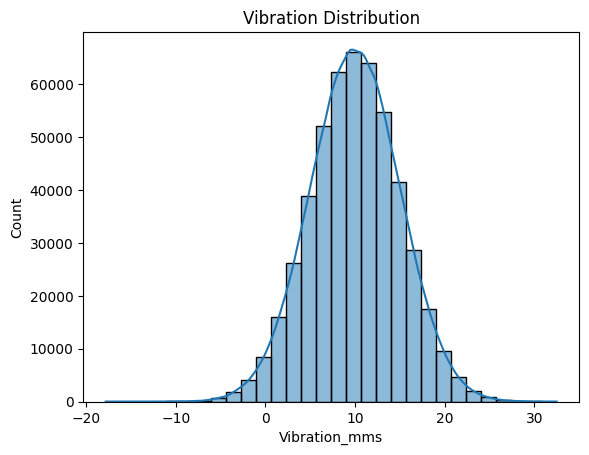

In [104]:
sns.histplot(df["Vibration_mms"], bins=30, kde=True)
plt.title("Vibration Distribution")
plt.show()

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [106]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [107]:
y_pred = model.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.96332

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.98      0.98     93994
        True       0.71      0.65      0.68      6006

    accuracy                           0.96    100000
   macro avg       0.85      0.82      0.83    100000
weighted avg       0.96      0.96      0.96    100000


Confusion Matrix:
 [[92442  1552]
 [ 2116  3890]]


In [112]:
import joblib
joblib.dump(model, "failure_model.pkl")
joblib.dump(X.columns.tolist(), "model_columns.pkl")
print("Model saved successfully")

Model saved successfully


In [110]:
df1 = pd.read_csv("factory_sensor.csv.xls")
m_types = set(df1["Machine_Type"])
print(m_types)
print([col for col in X.columns.tolist() if col.startswith("Machine_Type_")])

{'Vacuum_Packer', 'Laser_Cutter', 'Conveyor_Belt', 'XRay_Inspector', '3D_Printer', 'Injection_Molder', 'Industrial_Chiller', 'Carton_Former', 'Forklift_Electric', 'Heat_Exchanger', 'CMM', 'AGV', 'CNC_Mill', 'CNC_Lathe', 'Grinder', 'Mixer', 'Press_Brake', 'Labeler', 'Pump', 'Valve_Controller', 'Shuttle_System', 'Furnace', 'Compressor', 'Automated_Screwdriver', 'Robot_Arm', 'Crane', 'Hydraulic_Press', 'Vision_System', 'Shrink_Wrapper', 'Boiler', 'Palletizer', 'Pick_and_Place', 'Dryer'}
['Machine_Type_AGV', 'Machine_Type_Automated_Screwdriver', 'Machine_Type_Boiler', 'Machine_Type_CMM', 'Machine_Type_CNC_Lathe', 'Machine_Type_CNC_Mill', 'Machine_Type_Carton_Former', 'Machine_Type_Compressor', 'Machine_Type_Conveyor_Belt', 'Machine_Type_Crane', 'Machine_Type_Dryer', 'Machine_Type_Forklift_Electric', 'Machine_Type_Furnace', 'Machine_Type_Grinder', 'Machine_Type_Heat_Exchanger', 'Machine_Type_Hydraulic_Press', 'Machine_Type_Industrial_Chiller', 'Machine_Type_Injection_Molder', 'Machine_Type_